## Business Problem Statement


Subscription-based digital platforms rely heavily on recurring revenue generated from active users. However, many platforms experience **revenue leakage** due to factors such as customer churn, payment failures, low user engagement, and ineffective customer acquisition channels.

Streaming services similar to modern OTT platforms operate in a highly competitive environment where retaining customers and maintaining consistent revenue streams is critical. If users cancel subscriptions frequently, fail to complete payments, or engage very little with the platform, it directly impacts the company's revenue stability and growth.

The objective of this project is to analyze a simulated dataset representing a digital streaming subscription platform. The analysis aims to identify patterns that contribute to revenue loss and customer churn by examining user behavior, subscription plans, payment trends, and engagement metrics.

Through exploratory data analysis and business metric calculations, this project will help answer key questions such as:

* What is the overall **churn rate** of the platform?
* Which **subscription plans** experience the highest churn?
* Does **low watch activity** increase the likelihood of churn?
* Which **payment methods** show higher failure rates?
* Which **acquisition channels** bring the most valuable users?

The insights derived from this analysis will help simulate how a data analyst can support business teams in improving customer retention, reducing revenue leakage, and optimizing subscription strategies.


## Data Dictionary

| Column      | Meaning                                         |
| ----------- | ----------------------------------------------- |
| **user_id** | Unique identifier for each user in the platform |
| --------------------- | ---------------------------------------------------------------------- |
| **subscription_plan** | Type of plan the user subscribed to (Mobile, Basic, Standard, Premium) |
| **monthly_price**     | Monthly subscription price for the selected plan (₹)                   |
| **signup_date**       | Date when the user started their subscription                          |
| **cancel_date**       | Date when the user cancelled the subscription (null if still active)   |
| ----------------------|-------------------------------------------------------------------------- |
| **watch_hours**       | Total hours the user spent watching content in a month                   |
| **content_preference**| Type of content the user watches most (Movies, TV Series, Sports, Kids, Documentary) |
| **device_type**       | Device most frequently used by the user to watch content(Mobile,Smart TV,Laptop,Tablet)|
| ----------------------|----------------------------------------------------------------------- |
| **payment_method** | Payment option used for subscription payments(UPI,Credit C,Debit C,Net Banking, Wallet)|
| **payment_status** | Indicates whether the payment was successful or failed                    |
| ----------------------- | -------------------------------------------------------------------- |
| **acquisition_channel** | Marketing channel through which the user joined the platform (Ads,Organic,Referral, App Store) |
| **trial_user**          | Indicates whether the user initially signed up for a free trial (Yes / No) |
| ------------- | --------------------------------- |
| **country**   | Country where the user is located |
| **age_group** | Age category of the user          |
| ------------------------------ | --------------------------------------------------------------- |
| **churn_flag**               | Indicates whether the user cancelled the subscription (1 = churned, 0 = active) |
| **subscription_duration_days** | Total number of days the user stayed subscribed                          |
| **subscription_months**        | Subscription duration converted into months                              |
| **revenue_generated**          | Total revenue generated from that user                                   |


## Loading the Dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/raw/streamwave_dataset_v2.csv")
df.head()

,user_id,subscription_plan,monthly_price,signup_date,cancel_date,watch_hours,content_preference,device_type,payment_method,payment_status,acquisition_channel,trial_user,country,age_group
0,1,Mobile,149,2025-07-01,2025-07-12,22.66,Documentary,Tablet,UPI,Success,Referral,Yes,UK,35-44
1,2,Basic,299,2025-07-23,NaN,27.72,Sports,Tablet,Credit Card,Success,App Store,No,UAE,18-24
2,3,Standard,499,2025-02-28,NaN,63.21,Movies,Laptop,Wallet,Success,Ads,Yes,UK,18-24
3,4,Mobile,149,2025-07-05,NaN,36.75,Movies,Smart TV,UPI,Success,Referral,No,India,18-24
4,5,Standard,499,2025-04-21,NaN,44.07,Sports,Mobile,UPI,Success,Referral,No,Canada,18-24


In [3]:
df.shape

(252500, 14)

In [4]:
df.describe()

,user_id,monthly_price,watch_hours
count,252500.000000,252500.000000,252500.000000
mean,124996.819311,344.190531,34.012015
std,72174.393396,196.014735,17.719921
min,1.000000,-100.000000,0.000000
25%,62488.750000,149.000000,20.880000
50%,124984.500000,299.000000,30.530000
75%,187492.250000,499.000000,44.810000
max,250000.000000,699.000000,122.750000


## Data Inspection & Data Cleaning


### 1 Inspect Dataset Structure

First, we examine the structure of the dataset to understand:
- number of rows and columns
- column names
- data types
- missing values

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 252500 entries, 0 to 252499
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   user_id              252500 non-null  int64  
 1   subscription_plan    247449 non-null  str    
 2   monthly_price        252500 non-null  int64  
 3   signup_date          252500 non-null  str    
 4   cancel_date          69469 non-null   str    
 5   watch_hours          252500 non-null  float64
 6   content_preference   252500 non-null  str    
 7   device_type          247451 non-null  str    
 8   payment_method       247654 non-null  str    
 9   payment_status       252500 non-null  str    
 10  acquisition_channel  252500 non-null  str    
 11  trial_user           252500 non-null  str    
 12  country              247456 non-null  str    
 13  age_group            252500 non-null  str    
dtypes: float64(1), int64(2), str(11)
memory usage: 27.0 MB


### 2 Checking Missing Values

Missing values can affect analysis results, so we check how many null values exist in each column.

In [6]:
df.isnull().sum()

user_id                     0
subscription_plan        5051
monthly_price               0
signup_date                 0
cancel_date            183031
watch_hours                 0
content_preference          0
device_type              5049
payment_method           4846
payment_status              0
acquisition_channel         0
trial_user                  0
country                  5044
age_group                   0
dtype: int64

### 3 Handle Missing Values

In [7]:
cols_to_fix = ['subscription_plan', 'payment_method', 'device_type', 'country']
df[cols_to_fix] = df[cols_to_fix].fillna("Unknown")

In [8]:
df.isnull().sum()

user_id                     0
subscription_plan           0
monthly_price               0
signup_date                 0
cancel_date            183031
watch_hours                 0
content_preference          0
device_type                 0
payment_method              0
payment_status              0
acquisition_channel         0
trial_user                  0
country                     0
age_group                   0
dtype: int64

### 4 Checking Duplicate Records

Duplicate records can distort metrics such as revenue or churn, so we identify whether duplicate rows exist.

In [9]:
df.duplicated().sum()

np.int64(2261)

### 5 Remove Duplicate Rows

In [10]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

### 6 Fixing Data Types

Date columns must be converted to proper datetime format for time-based analysis such as churn calculation and subscription duration.

In [11]:
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')
df['cancel_date'] = pd.to_datetime(df['cancel_date'], errors='coerce')

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 250239 entries, 0 to 252495
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   user_id              250239 non-null  int64         
 1   subscription_plan    250239 non-null  str           
 2   monthly_price        250239 non-null  int64         
 3   signup_date          248977 non-null  datetime64[us]
 4   cancel_date          68823 non-null   datetime64[us]
 5   watch_hours          250239 non-null  float64       
 6   content_preference   250239 non-null  str           
 7   device_type          250239 non-null  str           
 8   payment_method       250239 non-null  str           
 9   payment_status       250239 non-null  str           
 10  acquisition_channel  250239 non-null  str           
 11  trial_user           250239 non-null  str           
 12  country              250239 non-null  str           
 13  age_group            250239 no

### 7 Validate Columns

In [13]:
categorical_cols = ['subscription_plan', 'content_preference','device_type','payment_method','payment_status','acquisition_channel','trial_user','country','age_group']

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())



Column: subscription_plan
subscription_plan
Mobile        84302
Basic         71972
Standard      48137
Premium       35998
Unknown        5006
 Mobile        1678
 Basic         1435
 Standard       961
 Premium        750
Name: count, dtype: int64

Column: content_preference
content_preference
Movies         62763
TV Series      62578
Documentary    62550
Kids           41447
Sports         20901
Name: count, dtype: int64

Column: device_type
device_type
Mobile      89681
Smart TV    70789
Laptop      49097
Tablet      35666
Unknown      5006
Name: count, dtype: int64

Column: payment_method
payment_method
UPI            82189
Credit Card    59119
Debit Card     35200
Net Banking    35125
Wallet         23780
CREDIT_CARD     5048
credit card     4970
Unknown         4808
Name: count, dtype: int64

Column: payment_status
payment_status
Success    214868
Failed      35371
Name: count, dtype: int64

Column: acquisition_channel
acquisition_channel
Referral     63021
App Store    62583
A

In [14]:
df['subscription_plan'].value_counts()

subscription_plan
Mobile        84302
Basic         71972
Standard      48137
Premium       35998
Unknown        5006
 Mobile        1678
 Basic         1435
 Standard       961
 Premium        750
Name: count, dtype: int64

### 8 Fix Category Inconsistencies

In [15]:
df['payment_method'] = df['payment_method'].replace({
    "credit card": "Credit Card",
    "CREDIT_CARD": "Credit Card"
})
df['payment_method'].value_counts()

payment_method
UPI            82189
Credit Card    69137
Debit Card     35200
Net Banking    35125
Wallet         23780
Unknown         4808
Name: count, dtype: int64

In [16]:
df['payment_status']=df['payment_status'].replace({'success':'Success'})
df['payment_status'].value_counts()

payment_status
Success    214868
Failed      35371
Name: count, dtype: int64

### 9 Remove Whitespace Issues

In [17]:
df['subscription_plan'] = df['subscription_plan'].str.strip()

In [18]:
for col in categorical_cols:
    df[col] = df[col].str.strip()
    df[col] = df[col].str.title()

In [19]:
df['payment_method'] = df['payment_method'].replace({
    "Upi": "UPI"
})
df['country'] = df['country'].replace({
    "Usa": "USA",
    "Uae":"UAE",
    "Uk":"UK"
})

In [20]:
df.head()

,user_id,subscription_plan,monthly_price,signup_date,cancel_date,watch_hours,content_preference,device_type,payment_method,payment_status,acquisition_channel,trial_user,country,age_group
0,1,Mobile,149,2025-07-01,2025-07-12,22.66,Documentary,Tablet,UPI,Success,Referral,Yes,UK,35-44
1,2,Basic,299,2025-07-23,NaT,27.72,Sports,Tablet,Credit Card,Success,App Store,No,UAE,18-24
2,3,Standard,499,2025-02-28,NaT,63.21,Movies,Laptop,Wallet,Success,Ads,Yes,UK,18-24
3,4,Mobile,149,2025-07-05,NaT,36.75,Movies,Smart Tv,UPI,Success,Referral,No,India,18-24
4,5,Standard,499,2025-04-21,NaT,44.07,Sports,Mobile,UPI,Success,Referral,No,Canada,18-24


### 10 Fix Invalid Numerical Values

In [21]:
df = df[df['monthly_price'] > 0]
df.shape

(248988, 14)

### 11 Detect Outliers

In [22]:
df['watch_hours'].describe()

count    248988.000000
mean         34.017078
std          17.722098
min           0.000000
25%          20.890000
50%          30.530000
75%          44.820000
max         122.750000
Name: watch_hours, dtype: float64

In [23]:
df = df[df['watch_hours'] < 200]

In [24]:
df.info()

<class 'pandas.DataFrame'>
Index: 248988 entries, 0 to 252495
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   user_id              248988 non-null  int64         
 1   subscription_plan    248988 non-null  str           
 2   monthly_price        248988 non-null  int64         
 3   signup_date          247736 non-null  datetime64[us]
 4   cancel_date          68495 non-null   datetime64[us]
 5   watch_hours          248988 non-null  float64       
 6   content_preference   248988 non-null  str           
 7   device_type          248988 non-null  str           
 8   payment_method       248988 non-null  str           
 9   payment_status       248988 non-null  str           
 10  acquisition_channel  248988 non-null  str           
 11  trial_user           248988 non-null  str           
 12  country              248988 non-null  str           
 13  age_group            248988 no

In [25]:
df.describe()

,user_id,monthly_price,signup_date,cancel_date,watch_hours
count,248988.000000,248988.000000,247736,68495,248988.000000
mean,125015.952383,346.427988,2024-09-19 18:03:15.304679,2025-06-20 20:07:40.202934,34.017078
min,1.000000,149.000000,2023-03-23 00:00:00,2023-03-30 00:00:00,0.000000
25%,62513.750000,149.000000,2023-12-21 00:00:00,2025-01-28 00:00:00,20.890000
50%,125017.500000,299.000000,2024-09-20 00:00:00,2025-08-28 00:00:00,30.530000
75%,187514.250000,499.000000,2025-06-21 00:00:00,2026-01-06 00:00:00,44.820000
max,250000.000000,699.000000,2026-03-22 00:00:00,2026-03-22 00:00:00,122.750000
std,72168.457447,193.982383,NaN,NaN,17.722098


##  Feature Engineering

Feature engineering involves creating new columns that help measure key business metrics such as churn rate, revenue generation, and subscription duration.

These derived fields allow deeper analysis of customer behavior and revenue leakage.

In [26]:
# 1 Subscription Duration ---> Calculate the number of days a user remained subscribed.
   #   Still active users → assume cancel_date = today 
   # df['subscription_duration'] = (df['cancel_date'] - df['signup_date']).dt.days

today = pd.Timestamp.today()

df['subscription_duration'] = (
    df['cancel_date'].fillna(today) - df['signup_date']
).dt.days

df['subscription_duration']


0          11.0
1         244.0
2         389.0
3         262.0
4         337.0
          ...  
252436     40.0
252445     20.0
252450      NaN
252491    248.0
252495    211.0
Name: subscription_duration, Length: 248988, dtype: float64

In [27]:
# 2 Churn Flag ---> A churned user is a user who cancelled their subscription.
df['churn_flag'] = df['cancel_date'].notna().astype(int)
df['churn_flag'] 

0         1
1         0
2         0
3         0
4         0
         ..
252436    0
252445    1
252450    0
252491    0
252495    0
Name: churn_flag, Length: 248988, dtype: int64

In [28]:
# 3 Active Subscription ---> Identify whether a subscription is currently active.
df['active_subscription'] = df['cancel_date'].isna().astype(int)


In [29]:
# 4 Revenue Generated ---> Calculate the revenue generated by each customer based on subscription duration.

df['subscription_months'] = df['subscription_duration'] / 30    #First convert duration to months
df['revenue_generated'] = df['subscription_months'] * df['monthly_price'] 

In [30]:
# 5 Payment Failure Flag ---> Identify transactions where the payment failed.
df['payment_failure_flag'] = (df['payment_status'] == 'Failed').astype(int)

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand patterns in the dataset and identify factors affecting revenue generation, churn, and customer engagement.

The analysis focuses on key business questions relevant to subscription-based platforms.

### 1 Platform Overview

Understanding the overall user base helps evaluate platform scale and customer retention.

Metrics analyzed:
- Total users
- Active users
- Churned users

In [31]:
df.info()

<class 'pandas.DataFrame'>
Index: 248988 entries, 0 to 252495
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                248988 non-null  int64         
 1   subscription_plan      248988 non-null  str           
 2   monthly_price          248988 non-null  int64         
 3   signup_date            247736 non-null  datetime64[us]
 4   cancel_date            68495 non-null   datetime64[us]
 5   watch_hours            248988 non-null  float64       
 6   content_preference     248988 non-null  str           
 7   device_type            248988 non-null  str           
 8   payment_method         248988 non-null  str           
 9   payment_status         248988 non-null  str           
 10  acquisition_channel    248988 non-null  str           
 11  trial_user             248988 non-null  str           
 12  country                248988 non-null  str           
 13  

In [32]:
total_users = df['user_id'].nunique()

active_users = df['active_subscription'].sum()

churned_users = df['churn_flag'].sum()

print("Total Users:", total_users)
print("Active Users:", active_users)
print("Churned Users:", churned_users)
print("Sum of active users + churned users:",active_users+churned_users)

Total Users: 248750
Active Users: 180493
Churned Users: 68495
Sum of active users + churned users: 248988


In [33]:
dup_users = df[df['user_id'].duplicated(keep=False)]
dup_users.sort_values('user_id')

,user_id,subscription_plan,monthly_price,signup_date,cancel_date,watch_hours,content_preference,device_type,payment_method,payment_status,acquisition_channel,trial_user,country,age_group,subscription_duration,churn_flag,active_subscription,subscription_months,revenue_generated,payment_failure_flag
1866,1867,Basic,299,2025-01-13,2025-02-03,34.39,Kids,Mobile,Credit Card,Success,Referral,Yes,India,18-24,21.0,1,0,0.700000,209.300000,0
251046,1867,Basic,299,2025-01-13,2025-02-03,34.39,Kids,Mobile,Credit Card,Success,Referral,Yes,India,18-24,21.0,1,0,0.700000,209.300000,0
250456,6235,Mobile,149,2023-10-01,2024-01-16,28.88,Tv Series,Mobile,Credit Card,Success,Ads,Yes,UK,25-34,107.0,1,0,3.566667,531.433333,0
6234,6235,Mobile,149,2023-10-01,2024-01-16,28.88,Tv Series,Mobile,Credit Card,Success,Ads,Yes,UK,25-34,107.0,1,0,3.566667,531.433333,0
6381,6382,Premium,699,2023-08-12,NaT,107.02,Tv Series,Laptop,Credit Card,Success,App Store,No,UK,55+,955.0,0,1,31.833333,22251.500000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247663,247664,Standard,499,2025-02-11,2025-10-31,57.40,Documentary,Tablet,Wallet,Success,App Store,Yes,India,45-54,262.0,1,0,8.733333,4357.933333,0
248664,248665,Mobile,149,2023-08-20,2023-08-24,12.92,Movies,Laptop,Wallet,Success,Referral,Yes,Canada,25-34,4.0,1,0,0.133333,19.866667,0
252212,248665,Mobile,149,2023-08-20,2023-08-24,12.92,Movies,Laptop,Credit Card,Success,Referral,Yes,Canada,25-34,4.0,1,0,0.133333,19.866667,0
250903,249563,Mobile,149,2025-02-02,NaT,44.99,Movies,Mobile,Debit Card,Success,Ads,Yes,Canada,18-24,415.0,0,1,13.833333,2061.166667,0


In [34]:
#found that rows with same user id have everything same except the payment type.
#so keeping the first row from the duplicate set for each user. 
df = df.drop_duplicates(subset='user_id', keep='first')

In [35]:
total_users = df['user_id'].nunique()

active_users = df['active_subscription'].sum()

churned_users = df['churn_flag'].sum()

print("Total Users:", total_users)
print("Active Users:", active_users)
print("Churned Users:", churned_users)
print("Sum of active users + churned users:",active_users+churned_users)

Total Users: 248750
Active Users: 180314
Churned Users: 68436
Sum of active users + churned users: 248750


### 2 Revenue by Subscription Plan

This analysis identifies which subscription plans contribute the most revenue.

In [36]:
revenue_by_plan = df.groupby('subscription_plan')['revenue_generated'].sum().sort_values(ascending=False)

revenue_by_plan.apply(lambda x: f"₹{x/10000000:.2f} Cr")

subscription_plan
Premium     ₹42.84 Cr
Standard    ₹40.06 Cr
Basic       ₹33.78 Cr
Mobile      ₹19.20 Cr
Unknown      ₹2.79 Cr
Name: revenue_generated, dtype: str

<Axes: title={'center': 'Revenue by Subscription Plan'}, xlabel='subscription_plan'>

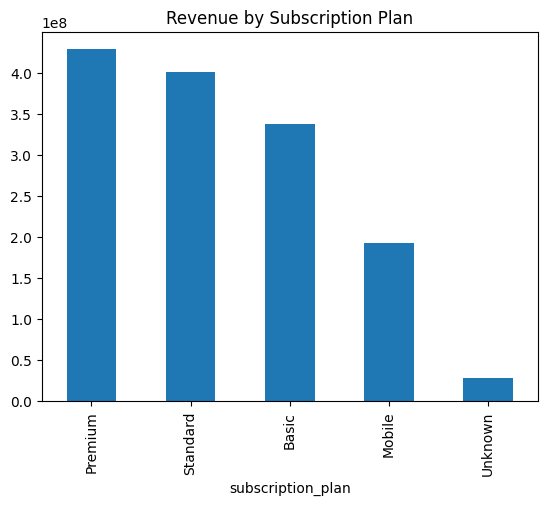

In [37]:
import matplotlib 
revenue_by_plan.plot(kind='bar', title="Revenue by Subscription Plan")

### 3 Churn Rate by Subscription Plan

This analysis identifies which subscription plans experience the highest customer churn.

In [38]:
churn_by_plan = df.groupby('subscription_plan')['churn_flag'].mean().sort_values(ascending=False)

churn_by_plan*100

subscription_plan
Mobile      34.819193
Basic       30.240206
Unknown     27.173913
Standard    19.880321
Premium     15.217748
Name: churn_flag, dtype: float64

### 4 Revenue by Country
This analysis helps identify the most profitable geographic markets.

In [39]:
revenue_by_country = df.groupby('country')['revenue_generated'].sum().astype(int).sort_values(ascending=False)

revenue_by_country.apply(lambda x: f"₹{x/10000000:.3f} Cr")

country
India      ₹54.027 Cr
USA        ₹27.161 Cr
UAE        ₹20.549 Cr
UK         ₹20.340 Cr
Canada     ₹13.813 Cr
Unknown     ₹2.781 Cr
Name: revenue_generated, dtype: str

### 5 Churn Rate by Acquisition Channel

Different acquisition channels may attract users with varying retention rates.

In [40]:
churn_by_channel = df.groupby('acquisition_channel')['churn_flag'].mean().sort_values(ascending=False)

churn_by_channel*100

acquisition_channel
Organic      27.660983
App Store    27.571573
Ads          27.420162
Referral     27.396232
Name: churn_flag, dtype: float64

### 6 Engagement Analysis by Device Type

Watch hours help measure customer engagement with the platform.

In [41]:
watch_by_device = df.groupby('device_type')['watch_hours'].mean().sort_values(ascending=False)

watch_by_device

device_type
Unknown     34.287947
Mobile      34.076259
Tablet      34.016075
Smart Tv    33.989196
Laptop      33.919948
Name: watch_hours, dtype: float64

### 7 Payment Failure Analysis

Payment failures can directly contribute to revenue leakage.

In [42]:
payment_failure_rate = df['payment_failure_flag'].mean() * 100

print("Payment Failure Rate:", round(payment_failure_rate,2), "%")

Payment Failure Rate: 14.14 %


##  Business Metrics Calculation

Subscription businesses track specific key performance indicators (KPIs) to evaluate growth, customer retention, and revenue performance.

In this section, we calculate important subscription business metrics such as:
- Churn Rate
- Monthly Recurring Revenue (MRR)
- Average Revenue Per User (ARPU)
- Revenue Lost due to Churn
- Payment Failure Rate

### 1 Churn Rate

Churn rate indicates the percentage of users who cancelled their subscriptions during the observation period.

In [43]:
churn_rate = df['churn_flag'].mean() * 100

print("Churn Rate:", round(churn_rate,2), "%")

Churn Rate: 27.51 %


### 2 Monthly Recurring Revenue (MRR)

MRR represents the predictable monthly revenue generated from active subscriptions.

In [44]:
mrr = df[df['active_subscription'] == 1]['monthly_price'].sum()
mrr=mrr/10000000
print(f"Monthly Recurring Revenue (MRR):{ mrr:.2f} Cr")

Monthly Recurring Revenue (MRR):6.60 Cr


### 3 Average Revenue Per User (ARPU)

ARPU helps evaluate how much revenue is generated per user on average.

In [45]:
arpu = df['revenue_generated'].sum() / df['user_id'].nunique()

print("Average Revenue Per User (ARPU):", round(arpu,2))

Average Revenue Per User (ARPU): 5574.72


### 4 Revenue Lost Due to Churn

Revenue lost due to churn represents the total potential revenue lost from customers who cancelled their subscriptions.

In [46]:
revenue_lost = df[df['churn_flag'] == 1]['monthly_price'].sum()

print(f"Revenue Lost Due to Churn:{round(revenue_lost/10000000,4)} Cr")

Revenue Lost Due to Churn:2.0165 Cr


### 5 Payment Failure Rate

Payment failures can result in lost revenue if transactions are not successfully processed.

In [47]:
payment_failure_rate = df['payment_failure_flag'].mean() * 100

print(f"Payment Failure Rate: {round(payment_failure_rate,2)} %")

Payment Failure Rate: 14.14 %


##  Data Export for Power BI

The cleaned and feature-engineered dataset is exported for visualization in Power BI.

This dataset will be used to build dashboards and perform further analysis.

In [48]:
import os

# Create folder if not exists
os.makedirs("data/processed", exist_ok=True)

# Save cleaned dataset
df.to_csv("data/processed/streamwave_cleaned.csv", index=False)

###  Date Dimension Table

A date dimension table is created to support time-based analysis such as monthly revenue trends, churn trends, and seasonal patterns.

In [49]:
date_range = pd.date_range(
    start=df['signup_date'].min(),
    end=pd.Timestamp.today(),
    freq='D'
)

date_dim = pd.DataFrame({
    'date': date_range
})

date_dim['year'] = date_dim['date'].dt.year
date_dim['month'] = date_dim['date'].dt.month
date_dim['month_name'] = date_dim['date'].dt.month_name()
date_dim['quarter'] = date_dim['date'].dt.quarter
date_dim['day'] = date_dim['date'].dt.day

In [50]:
date_dim.head()

,date,year,month,month_name,quarter,day
0,2023-03-23,2023,3,March,1,23
1,2023-03-24,2023,3,March,1,24
2,2023-03-25,2023,3,March,1,25
3,2023-03-26,2023,3,March,1,26
4,2023-03-27,2023,3,March,1,27


In [51]:
import os

os.makedirs("data/processed", exist_ok=True)
date_dim.to_csv("data/processed/date_dimension.csv", index=False)

In [52]:
df.info()

<class 'pandas.DataFrame'>
Index: 248750 entries, 0 to 249999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                248750 non-null  int64         
 1   subscription_plan      248750 non-null  str           
 2   monthly_price          248750 non-null  int64         
 3   signup_date            247509 non-null  datetime64[us]
 4   cancel_date            68436 non-null   datetime64[us]
 5   watch_hours            248750 non-null  float64       
 6   content_preference     248750 non-null  str           
 7   device_type            248750 non-null  str           
 8   payment_method         248750 non-null  str           
 9   payment_status         248750 non-null  str           
 10  acquisition_channel    248750 non-null  str           
 11  trial_user             248750 non-null  str           
 12  country                248750 non-null  str           
 13  